# E010 — Audio UBM 64 components

Identical to E008 (+All augmentation, MFCC 13+Δ+ΔΔ, MAP r=16, LOSO 3-fold, seed=67)
but with **UBM_COMPONENTS = 64** instead of 32.

Baseline for comparison: E008 +All → fold0=3.47%, fold1=8.33%, fold2=0.83%, mean=4.21±3.11%

In [1]:
from pathlib import Path
import sys, copy
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc
from scipy.special import logsumexp
from scipy.stats import norm as scipy_norm
import pandas as pd

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

COLORS = {
    "target":    "#E74C3C",
    "nontarget": "#2E86AB",
    "green":     "#27AE60",
    "purple":    "#8E44AD",
    "gray":      "#95A5A6",
    "orange":    "#E67E22",
}
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA = Path("../data").resolve()
manifest = load_manifest(DATA)
y_all = manifest["label"].to_numpy()
SEED = 67
UBM_COMPONENTS = 64   # <-- only change from E008
MAP_R = 16.0

print(f"{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target")
print(f"UBM_COMPONENTS = {UBM_COMPONENTS}  (E008 was 32)")

222 samples — 30 target, 192 non-target
UBM_COMPONENTS = 64  (E008 was 32)


## 1. Helper functions (identical to E008)

In [2]:
def find_wav(stem: str, data_dir: Path) -> Path:
    for sf in ["target_train", "target_dev", "non_target_train", "non_target_dev"]:
        p = data_dir / sf / (stem + ".wav")
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def aug_noise(y: np.ndarray, snr_db: float = 20.0, rng: np.random.Generator = None) -> np.ndarray:
    """Add white noise at target SNR."""
    signal_power = np.mean(y ** 2) + 1e-10
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_power), len(y)).astype(y.dtype)
    return y + noise


def aug_speed(y: np.ndarray, rate_range=(0.9, 1.1), rng: np.random.Generator = None) -> np.ndarray:
    """Random time stretch without changing pitch."""
    rate = rng.uniform(*rate_range)
    return librosa.effects.time_stretch(y, rate=rate)


def extract_mfcc(y: np.ndarray, sr: int, n_mfcc: int = 13) -> np.ndarray:
    """MFCC + delta + delta-delta + CMN. Returns (T, 39)."""
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc   = np.vstack([mfcc, delta, delta2]).T
    mfcc  -= mfcc.mean(axis=0)  # CMN
    return mfcc


def load_and_augment(wav_path: Path, config: str, rng: np.random.Generator):
    """
    Load WAV and return list of (y, sr) tuples.
    config='all': [original, noisy, speed-perturbed]
    """
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    samples = [(y, sr)]
    if config in ("noise", "all"):
        samples.append((aug_noise(y, snr_db=20.0, rng=rng), sr))
    if config in ("speed", "all"):
        samples.append((aug_speed(y, rng=rng), sr))
    return samples


def extract_batch(df: pd.DataFrame, data_dir: Path, config: str, seed: int):
    """Extract MFCC frames for all samples with augmentation."""
    rng = np.random.default_rng(seed)
    all_mfcc, all_labels = [], []
    for _, row in df.iterrows():
        for y_aug, sr in load_and_augment(find_wav(row["stem"], data_dir), config, rng):
            mfcc = extract_mfcc(y_aug, sr)
            all_mfcc.append(mfcc)
            all_labels.extend([row["label"]] * len(mfcc))
    return np.vstack(all_mfcc), np.array(all_labels)


def train_ubm(X: np.ndarray, n_components: int = 64, seed: int = 67) -> GaussianMixture:
    return GaussianMixture(
        n_components=n_components, covariance_type="diag",
        max_iter=200, random_state=seed,
    ).fit(X)


def map_adapt(ubm: GaussianMixture, X_target: np.ndarray, r: float = 16.0) -> GaussianMixture:
    log_prob   = ubm._estimate_log_prob(X_target)
    log_resp   = log_prob + np.log(ubm.weights_)
    log_resp  -= logsumexp(log_resp, axis=1, keepdims=True)
    resp       = np.exp(log_resp)
    n_k        = resp.sum(axis=0)
    mu_hat     = (resp.T @ X_target) / (n_k[:, None] + 1e-10)
    alpha      = n_k / (n_k + r)
    adapted    = copy.deepcopy(ubm)
    adapted.means_ = alpha[:, None] * mu_hat + (1 - alpha[:, None]) * ubm.means_
    return adapted


def score_utterance(wav_path: Path, adapted: GaussianMixture, ubm: GaussianMixture) -> float:
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    mfcc  = extract_mfcc(y, sr)
    return float((adapted.score_samples(mfcc) - ubm.score_samples(mfcc)).mean())


print("Helper functions defined.")

Helper functions defined.


## 2. Cross-validation — +All augmentation, UBM 64

UBM and MAP-adapted model trained on augmented train frames (+All: original + noisy + speed).
Val utterances always scored from original WAVs.

In [3]:
oof_scores   = np.full(len(manifest), np.nan)
fold_results = []

for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    train_df = manifest.loc[train_idx]
    val_df   = manifest.loc[val_idx]

    # Extract augmented train frames (only train fold!)
    X_train, y_train = extract_batch(train_df, DATA, "all", seed=SEED + fold_id)
    X_nt = X_train[y_train == 0]
    X_t  = X_train[y_train == 1]

    print(f"Fold {fold_id}: {len(X_t)} target frames, {len(X_nt)} non-target frames")

    ubm     = train_ubm(X_nt, n_components=UBM_COMPONENTS, seed=SEED)
    adapted = map_adapt(ubm, X_t, r=MAP_R)

    # Score val on ORIGINAL WAVs only
    for idx, row in val_df.iterrows():
        oof_scores[idx] = score_utterance(find_wav(row["stem"], DATA), adapted, ubm)

    val_scores = oof_scores[val_idx]
    val_labels = manifest.loc[val_idx, "label"].to_numpy()
    eer, _     = compute_eer(val_scores[val_labels == 1], val_scores[val_labels == 0])
    min_dcf, _ = compute_min_dcf(val_scores[val_labels == 1], val_scores[val_labels == 0])
    fold_results.append({"fold": fold_id, "eer": eer, "min_dcf": min_dcf})
    print(f"  → EER={eer*100:.2f}%, min-DCF={min_dcf:.4f}")

print("\nAll folds done.")

Fold 0: 15384 target frames, 170818 non-target frames


  → EER=9.17%, min-DCF=0.0833


Fold 1: 16614 target frames, 179923 non-target frames


  → EER=9.17%, min-DCF=0.0833


Fold 2: 17132 target frames, 188553 non-target frames


  → EER=0.83%, min-DCF=0.0167

All folds done.


## 3. Results table — E010 vs E008 baseline

In [4]:
eers   = [r["eer"] * 100 for r in fold_results]
dcfs   = [r["min_dcf"]   for r in fold_results]
mean_e = np.mean(eers)
std_e  = np.std(eers)
mean_d = np.mean(dcfs)

# E008 +All reference
e008_eers = [3.47, 8.33, 0.83]
e008_mean = np.mean(e008_eers)
e008_std  = np.std(e008_eers)

print(f"{'':20} {'F0 EER':>8} {'F1 EER':>8} {'F2 EER':>8} {'Mean':>8} {'Std':>8} {'min-DCF':>9}")
print("-" * 72)
print(f"{'E008 +All (32 comp)':20} {e008_eers[0]:>8.2f} {e008_eers[1]:>8.2f} {e008_eers[2]:>8.2f} "
      f"{e008_mean:>8.2f} {e008_std:>8.2f} {'0.0509':>9}")
print(f"{'E010 +All (64 comp)':20} {eers[0]:>8.2f} {eers[1]:>8.2f} {eers[2]:>8.2f} "
      f"{mean_e:>8.2f} {std_e:>8.2f} {mean_d:>9.4f}")
print("-" * 72)

delta = mean_e - e008_mean
print(f"\nΔ EER (E010 − E008): {delta:+.2f}%  ({'improvement' if delta < 0 else 'regression'})")

# OOF overall
eer_oof, _   = compute_eer(oof_scores[y_all == 1], oof_scores[y_all == 0])
dcf_oof, thr = compute_min_dcf(oof_scores[y_all == 1], oof_scores[y_all == 0])
print(f"OOF overall: EER={eer_oof*100:.2f}%, min-DCF={dcf_oof:.4f}, threshold={thr:.3f}")

                       F0 EER   F1 EER   F2 EER     Mean      Std   min-DCF
------------------------------------------------------------------------
E008 +All (32 comp)      3.47     8.33     0.83     4.21     3.11    0.0509
E010 +All (64 comp)      9.17     9.17     0.83     6.39     3.93    0.0611
------------------------------------------------------------------------

Δ EER (E010 − E008): +2.18%  (regression)
OOF overall: EER=7.24%, min-DCF=0.1271, threshold=0.066


## 4. Visualizations

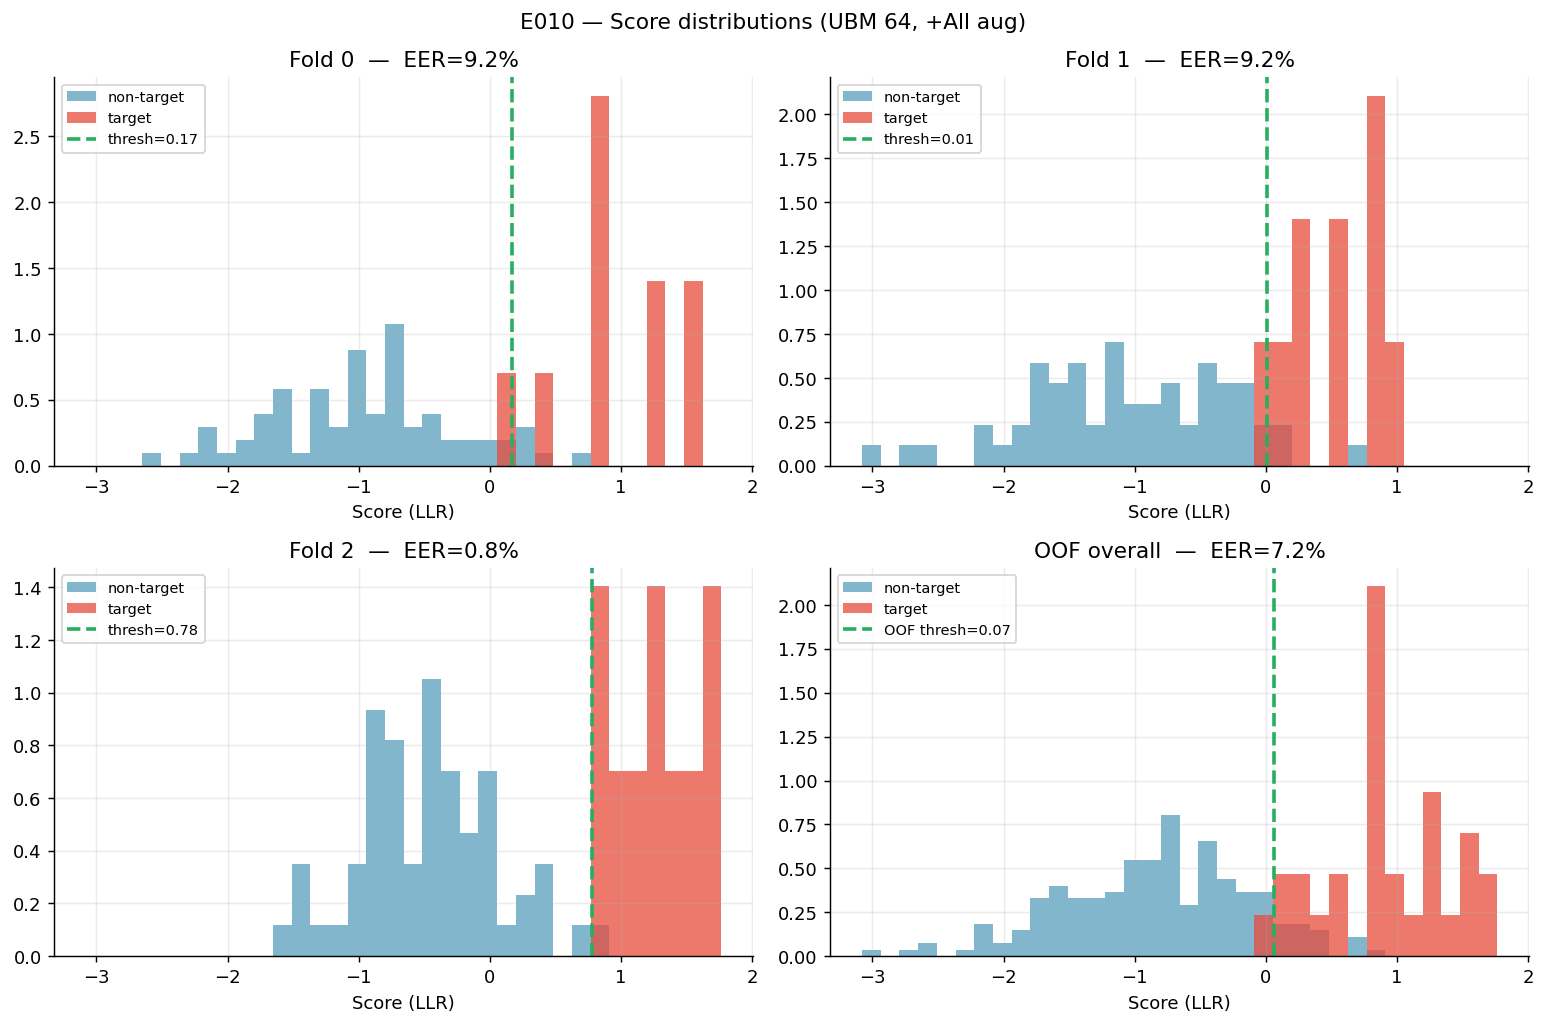

In [5]:
# Score distributions: per-fold (2×2) + OOF
fold_data = []
for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    fold_data.append({
        "scores": oof_scores[val_idx],
        "labels": manifest.loc[val_idx, "label"].to_numpy(),
    })

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
bin_edges = np.linspace(np.nanmin(oof_scores), np.nanmax(oof_scores), 35)

for i, (ax, fdata) in enumerate(zip(axes[:3], fold_data)):
    s, l = fdata["scores"], fdata["labels"]
    eer_f, thr_f = compute_eer(s[l == 1], s[l == 0])
    ax.hist(s[l == 0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"],
            label="non-target", density=True)
    ax.hist(s[l == 1], bins=bin_edges, alpha=0.75, color=COLORS["target"],
            label="target", density=True)
    ax.axvline(thr_f, color=COLORS["green"], ls="--", lw=2, label=f"thresh={thr_f:.2f}")
    ax.set_title(f"Fold {i}  —  EER={eer_f*100:.1f}%")
    ax.set_xlabel("Score (LLR)")
    ax.legend(fontsize=8)

ax = axes[3]
ax.hist(oof_scores[y_all == 0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"],
        label="non-target", density=True)
ax.hist(oof_scores[y_all == 1], bins=bin_edges, alpha=0.75, color=COLORS["target"],
        label="target", density=True)
ax.axvline(thr, color=COLORS["green"], ls="--", lw=2, label=f"OOF thresh={thr:.2f}")
ax.set_title(f"OOF overall  —  EER={eer_oof*100:.1f}%")
ax.set_xlabel("Score (LLR)")
ax.legend(fontsize=8)

plt.suptitle(f"E010 — Score distributions (UBM 64, +All aug)", fontsize=12)
plt.tight_layout()
plt.show()

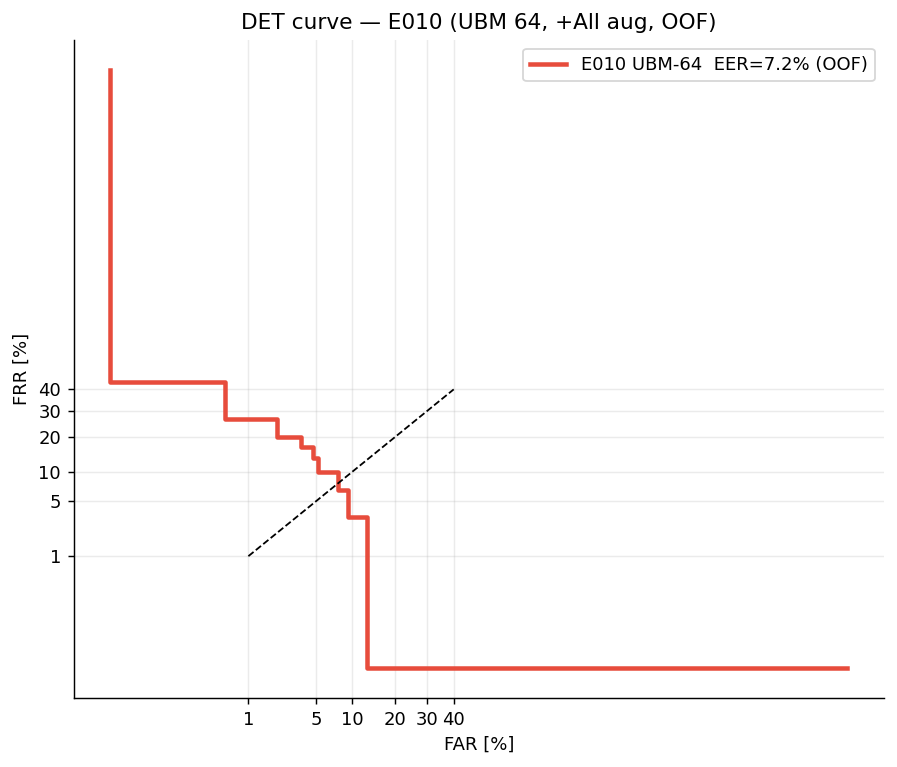

In [6]:
# DET curve
ticks = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
tick_pos    = [scipy_norm.ppf(t) for t in ticks]
tick_labels = [f"{int(t*100)}" for t in ticks]

fig, ax = plt.subplots(figsize=(7, 6))

valid = ~np.isnan(oof_scores)
fpr, tpr, _ = roc_curve(y_all[valid], oof_scores[valid])
far_c = np.clip(fpr, 1e-4, 1-1e-4)
frr_c = np.clip(1 - tpr, 1e-4, 1-1e-4)
ax.plot(scipy_norm.ppf(far_c), scipy_norm.ppf(frr_c),
        color=COLORS["target"], lw=2.5,
        label=f"E010 UBM-64  EER={eer_oof*100:.1f}% (OOF)")

ax.plot(tick_pos, tick_pos, "k--", lw=1)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_xlabel("FAR [%]")
ax.set_ylabel("FRR [%]")
ax.set_title("DET curve — E010 (UBM 64, +All aug, OOF)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

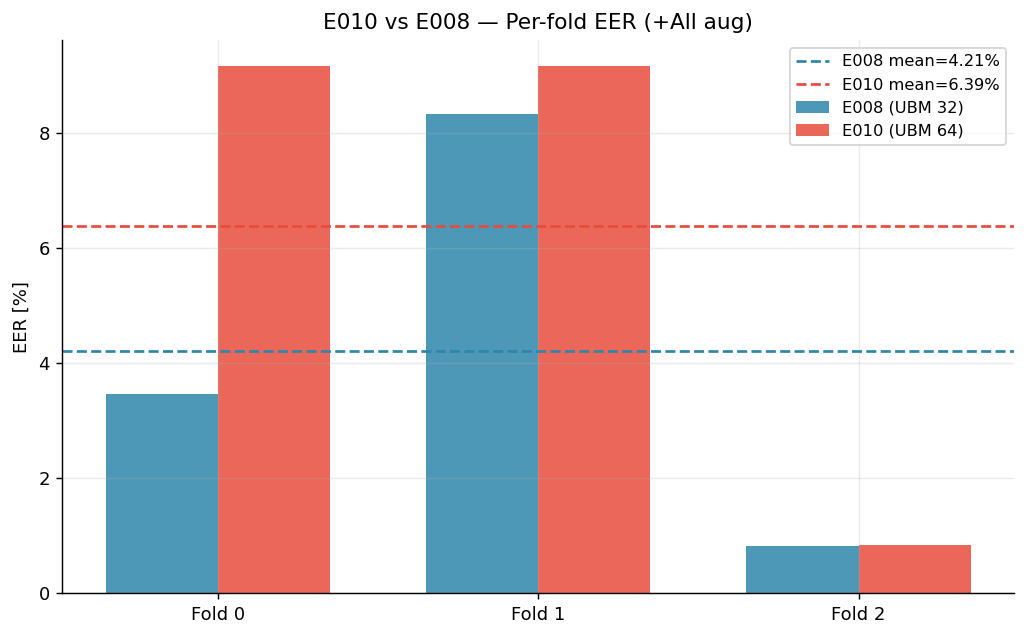

E008: 3.47 / 8.33 / 0.83  mean=4.21±3.11%
E010: 9.17 / 9.17 / 0.83  mean=6.39±3.93%
Delta: +2.18%


In [7]:
# Per-fold bar chart: E010 vs E008
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(3)
width = 0.35

ax.bar(x - width/2, e008_eers, width, label="E008 (UBM 32)",
       color=COLORS["nontarget"], alpha=0.85)
ax.bar(x + width/2, eers, width, label="E010 (UBM 64)",
       color=COLORS["target"], alpha=0.85)

# mean lines
ax.axhline(e008_mean, color=COLORS["nontarget"], ls="--", lw=1.5,
           label=f"E008 mean={e008_mean:.2f}%")
ax.axhline(mean_e, color=COLORS["target"], ls="--", lw=1.5,
           label=f"E010 mean={mean_e:.2f}%")

ax.set_xticks(x)
ax.set_xticklabels(["Fold 0", "Fold 1", "Fold 2"])
ax.set_ylabel("EER [%]")
ax.set_title("E010 vs E008 — Per-fold EER (+All aug)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"E008: {e008_eers[0]:.2f} / {e008_eers[1]:.2f} / {e008_eers[2]:.2f}  mean={e008_mean:.2f}±{e008_std:.2f}%")
print(f"E010: {eers[0]:.2f} / {eers[1]:.2f} / {eers[2]:.2f}  mean={mean_e:.2f}±{std_e:.2f}%")
print(f"Delta: {delta:+.2f}%")